# Digit Recognition using a Convolutional Neural Network

### 1. Setup & Imports

In [1]:
import random

# PyTorch and related libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader  # Helps load data in mini-batches
from torchvision import datasets, transforms

# For visualization
import matplotlib.pyplot as plt

# Device setup (GPU if available)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {DEVICE}")

Running on device: cpu


### 2. Load and Prepare the MNIST Dataset

**Each MNIST image is grayscale (1 channel) and 28x28 pixels.** We'll convert it to a PyTorch tensor and normalize pixel values.

In [2]:
DATA_DIR = "./data"  # Directory to store dataset
BATCH_SIZE_TRAIN = 64  # Number of images per training batch
BATCH_SIZE_TEST = 1000  # Number of images per test batch
RANDOM_SEED = 42  # Random seed for reproducibility

# Set random seeds (for reproducible results)
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Define image transformations
# - Convert to Tensor
# - Normalize pixel values (center around mean and scale by std)
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
)

# Load training and testing data
train_data = datasets.MNIST(
    root=DATA_DIR, train=True, download=True, transform=transform
)
test_data = datasets.MNIST(root=DATA_DIR, train=False, transform=transform)

# Create DataLoaders to handle batching and shuffling
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE_TRAIN, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE_TEST)

print(f"Training samples: {len(train_data):,}")
print(f"Testing samples: {len(test_data):,}")

Training samples: 60,000
Testing samples: 10,000


### 3. Define Our CNN Model

**This small CNN has two convolution layers and two fully connected layers. It learns to extract spatial features from the 28x28 images and output 10 class scores (digits 0–9).**

In [3]:
class DigitClassifierCNN(nn.Module):
    """
    A simple Convolutional Neural Network for recognizing
    handwritten digits (0–9) from the MNIST dataset.

    Architecture:
      - Two convolutional layers to extract image features
      - One max pooling layer to reduce spatial size
      - Two fully connected layers for classification
    """

    def __init__(self) -> None:
        super().__init__()
        # First convolution layer: input=1 (grayscale), output=32 filters, kernel=3x3
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1)

        # Second convolution layer: input=32 feature maps, output=64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1)

        # Fully connected layer: flatten 64x12x12 → 128 neurons
        self.fc1 = nn.Linear(64 * 12 * 12, 128)

        # Output layer: 128 neurons → 10 classes (digits 0–9)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Apply first convolution and ReLU activation
        x = F.relu(self.conv1(x))

        # Apply second convolution and ReLU activation
        x = F.relu(self.conv2(x))

        # Apply 2x2 max pooling to reduce image size by half
        x = F.max_pool2d(x, 2)

        # Flatten (batch_size, channels, height, width) → (batch_size, features)
        x = torch.flatten(x, 1)

        # Pass through fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        # Output raw scores (logits)
        return x


# Initialize the model and optimizer
LEARNING_RATE = 0.001  # Controls how fast the model updates weights
model = DigitClassifierCNN().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

DigitClassifierCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### 4. Training & Evaluation Loop

In [4]:
NUM_EPOCHS = 4

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0.0

    # Iterate through mini-batches
    for data, target in train_loader:
        data, target = data.to(DEVICE), target.to(DEVICE)

        # Reset gradients from the previous step
        optimizer.zero_grad()

        # Forward pass: compute predictions
        output = model(data)

        # Compute cross-entropy loss
        loss = F.cross_entropy(output, target)

        # Backward pass: compute gradients
        loss.backward()

        # Update model weights
        optimizer.step()

        total_loss += loss.item()

    # Switch to evaluation mode (no gradient calculation)
    model.eval()
    correct = 0

    # Evaluate model accuracy on test data
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()

    avg_loss = total_loss / len(train_loader)
    test_accuracy = 100.0 * correct / len(test_data)

    print(
        f"[Epoch {epoch}/{NUM_EPOCHS}] "
        f"Average Loss: {avg_loss:.4f} | "
        f"Test Accuracy: {test_accuracy:.2f}%"
    )

[Epoch 1/4] Average Loss: 0.1203 | Test Accuracy: 98.60%
[Epoch 2/4] Average Loss: 0.0365 | Test Accuracy: 98.85%
[Epoch 3/4] Average Loss: 0.0238 | Test Accuracy: 99.13%
[Epoch 4/4] Average Loss: 0.0144 | Test Accuracy: 98.98%


### 5. Visualize a Few Model Predictions

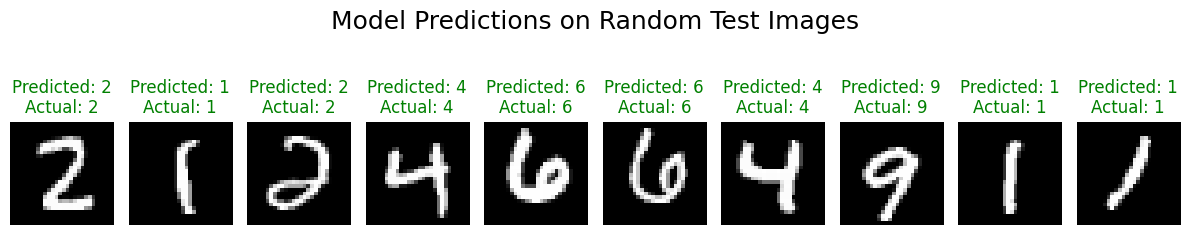

In [5]:
# Select 10 random test samples
indices = random.sample(range(len(test_data)), 10)
images = torch.stack([test_data[i][0] for i in indices])
labels = torch.tensor([test_data[i][1] for i in indices])

# Run model on the selected images
model.eval()
with torch.no_grad():
    outputs = model(images.to(DEVICE))
preds = outputs.argmax(dim=1).cpu()

# Plot the predictions
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(images[i][0], cmap="gray")

    # Check correctness and color accordingly
    correct = preds[i].item() == labels[i].item()
    color = "green" if correct else "red"

    plt.title(
        f"Predicted: {preds[i].item()}\nActual: {labels[i].item()}",
        color=color,
        fontsize=12,
    )
    plt.axis("off")

plt.suptitle("Model Predictions on Random Test Images", fontsize=18)
plt.tight_layout()
plt.show()